In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from scipy.special import gamma

import helium4plusplus as he4
import lm2m2 as x

plt.style.use('science')

In [2]:
lo = np.loadtxt('datfiles/phase_shifts/nonlocal_lo.txt')
nlo_p = np.loadtxt('datfiles/phase_shifts/nonlocal_nlo_p.txt')
nlo_np = np.loadtxt('datfiles/phase_shifts/nonlocal_nlo_np.txt')
lm2m2 =  np.loadtxt('datfiles/lm2m2_swave_phase_shifts.txt')

In [3]:
Ca = 2*np.pi/gamma(0.25)**2

def calculate_K0(a, beta6):
    return 1/(1-a/(beta6*Ca))


zs = np.loadtxt('gao/Z_functions.txt', dtype=np.complex128)

In [4]:
x.BETA6, he4.BETA6

(5.376986161622813, 5.54125)

In [5]:
K0 = calculate_K0(he4.A0, x.BETA6)

In [6]:
he4.R0 - gamma(1/4)**2/(3*np.pi)*(K0**2 + 1)/(K0 - 1)**2*x.BETA6

0.20612625228122106

In [7]:
K0p = he4.MASS*x.BETA6*np.pi*(K0 - 1)**2/gamma(1/4)**2 * \
    (he4.R0 - gamma(1/4)**2/(3*np.pi)*(K0**2 + 1)/(K0 - 1)**2*x.BETA6)

In [8]:
K0, K0p

(-0.026379378222013194, 0.023024964248854213)

In [9]:
tan_gao = (K0*zs[:, 5] - zs[:, 3]) / (zs[:, 2] - K0*zs[:, 4])

In [10]:
deltas_gao = np.arctan(tan_gao).real

In [11]:
def plot_phase_shifts(ps, ax, linestyle, color, label, index=-1):
    ax.plot(he4.BETA6*ps[:, 0], np.sin(ps[:, index])**2, linestyle=linestyle, color=color, label=label)

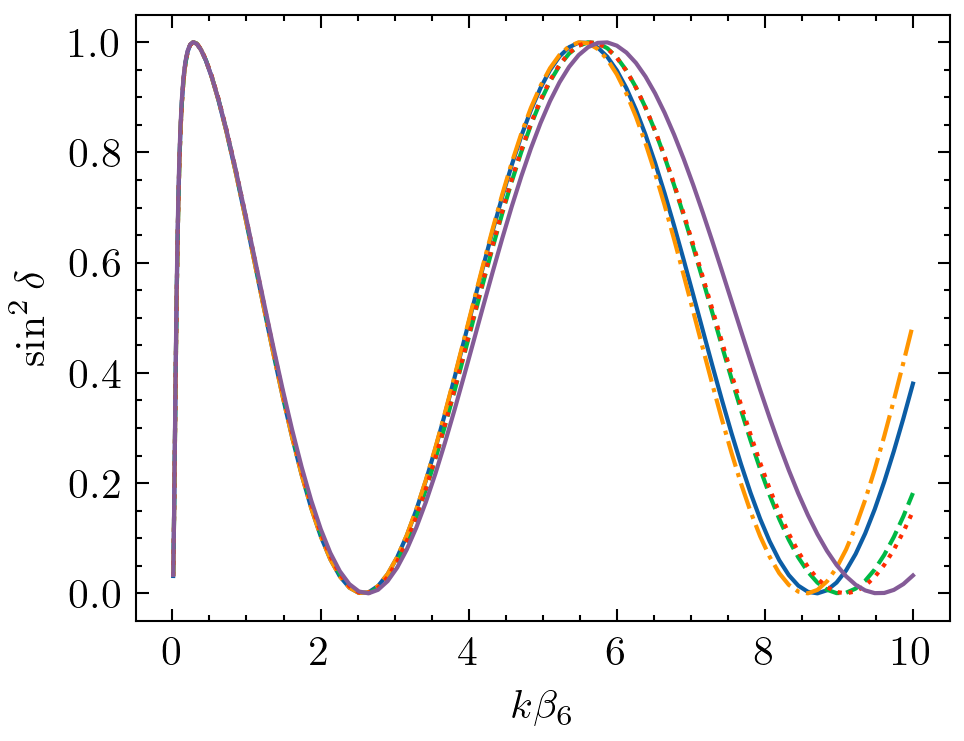

In [12]:
fig, ax = plt.subplots(dpi=300)
fig.patch.set_facecolor('white')

plot_phase_shifts(lo, ax, '-', 'C0', label='LO')
plot_phase_shifts(nlo_np, ax, '--', 'C1', label='NLO (non-pert)')
plot_phase_shifts(nlo_p, ax, '-.', 'C2', label='NLO (pert)', index=1)
plot_phase_shifts(lm2m2, ax, ':', 'C3', label='LM2M2')

ax.plot(np.sqrt(x.MASS*zs[:, 0].real)*x.BETA6, np.sin(deltas_gao)**2, color='C4', label=r'QDT')

# ax.legend()
ax.set_xlabel(r'$k\beta_6$')
ax.set_ylabel(r'$\sin^2\delta$');

# ax.set_xscale('log');

plt.savefig('figures/phase_shifts_lo_nlo_nlop_lm2m2.pdf', dpi=300)

In [13]:
R_min = 0.693
he4.BETA6 / R_min

7.996031746031746

In [14]:
def calculate_K(tand):
    return (tand * zs[:, 2].real + zs[:, 3].real) / (zs[:, 5].real + tand*zs[:, 4].real)

In [15]:
def plot_K(ps, ax, linestyle, color, label, index=-1):
    tand = np.tan(ps[:, index])
    ax.plot((he4.BETA6*ps[:, 0]/4)**2, calculate_K(tand), linestyle=linestyle, color=color, label=label)

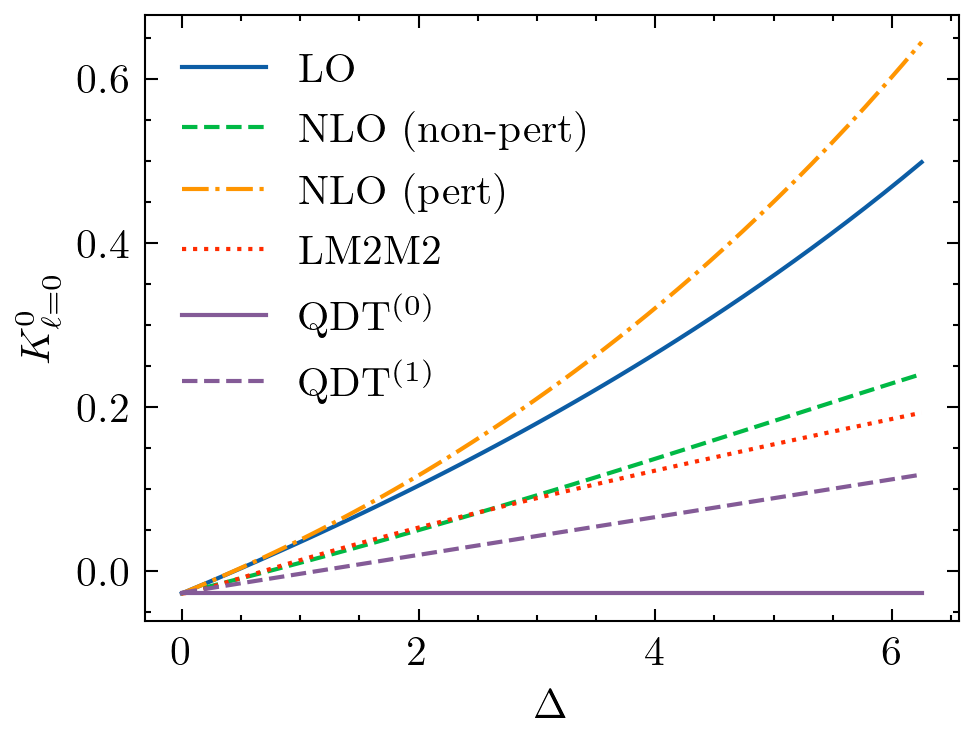

In [16]:
fig, ax = plt.subplots(dpi=300)
fig.patch.set_facecolor('white')

plot_K(lo, ax, '-', 'C0', label='LO')
plot_K(nlo_np, ax, '--', 'C1', label='NLO (non-pert)')
plot_K(nlo_p[:, [0, 1]], ax, '-.', 'C2', label='NLO (pert)', index=1)
plot_K(lm2m2, ax, ':', 'C3', label='LM2M2')

Ds = (np.sqrt(he4.MASS*zs[:, 0].real)*x.BETA6/4)**2
ax.plot(Ds, calculate_K(np.tan(deltas_gao)),
        color='C4', label=r'QDT${}^{(0)}$')
# ax.axvspan(0, 1/16, alpha=0.5, color='C6')
# ax.plot(Ds, K0 + K0p*16*he4.MASS*x.BETA6**2*Ds, color='C4', linestyle='--', label=r'QDT${}^{(1)}$')
ax.plot(Ds, K0 + K0p*Ds, color='C4', linestyle='--', label=r'QDT${}^{(1)}$')


ax.legend()
ax.set_xlabel(r'$\Delta$')
ax.set_ylabel(r'$K_{\ell=0}^0$');
# ax.set_ylim([-0.0275, -0.025])
# ax.set_xlim([1e-5, 1e-1])
# ax.set_xscale('log');

# plt.savefig('figures/K_lo_nlo_nlop_lm2m2.pdf', dpi=300)

(1e-05, 0.1)

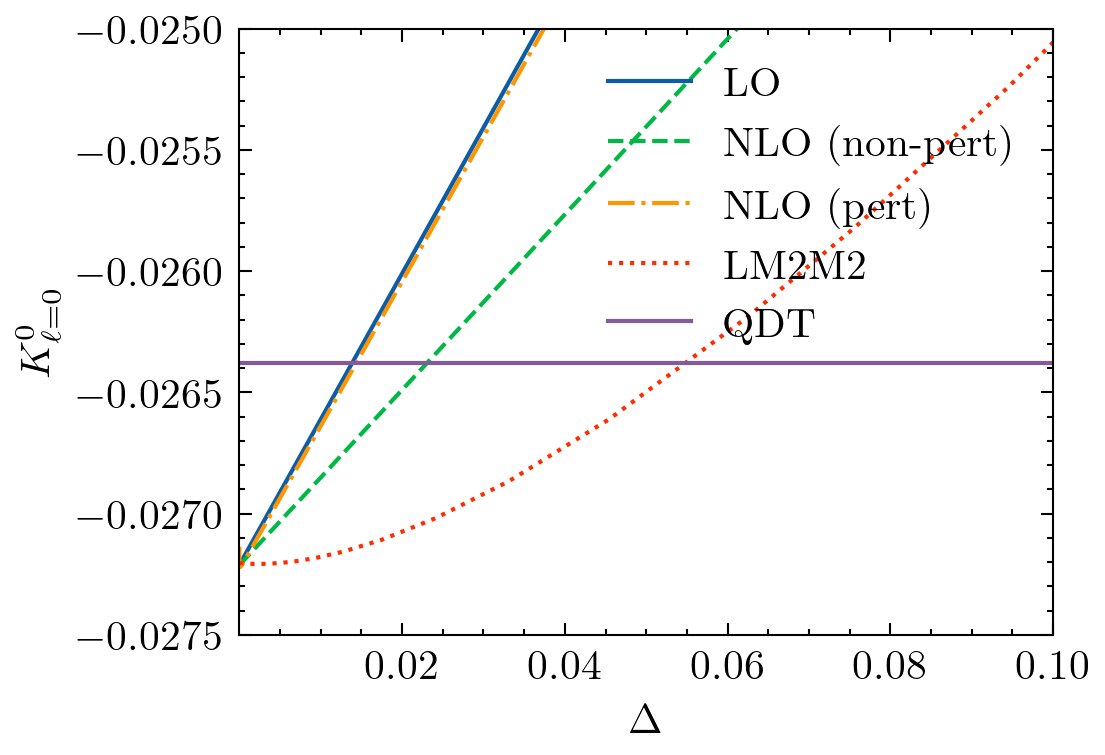

In [17]:
fig, ax = plt.subplots(dpi=300)
fig.patch.set_facecolor('white')

plot_K(lo, ax, '-', 'C0', label='LO')
plot_K(nlo_np, ax, '--', 'C1', label='NLO (non-pert)')
plot_K(nlo_p[:, [0, 1]], ax, '-.', 'C2', label='NLO (pert)', index=1)
plot_K(lm2m2, ax, ':', 'C3', label='LM2M2')

ax.plot((np.sqrt(he4.MASS*zs[:, 0].real)*he4.BETA6/4)**2, calculate_K(np.tan(deltas_gao)),
        color='C4', label=r'QDT')
# ax.axvspan(0, 1/16, alpha=0.5, color='C6')

ax.legend()
ax.set_xlabel(r'$\Delta$')
ax.set_ylabel(r'$K_{\ell=0}^0$');
ax.set_ylim([-0.0275, -0.025])
ax.set_xlim([1e-5, 1e-1])
# ax.set_xscale('log');

# plt.savefig('figures/K_lo_nlo_nlop_lm2m2.pdf', dpi=300)

In [18]:
def save_K(ps, name, index=-1):
    tand = np.tan(ps[:, index])
    np.savetxt('datfiles/phase_shifts/'+name,
               np.vstack(((he4.BETA6*ps[:, 0]/4)**2, calculate_K(tand))).T, header='Delta  K_0^0(Delta)')

In [19]:
save_K(lo, 'lo_K.txt')
save_K(nlo_np, 'nlo_np_K.txt')
save_K(nlo_p, 'nlo_p_K.txt', 1)
save_K(lm2m2, 'lm2m2_K.txt')

In [20]:
np.savetxt('datfiles/phase_shifts/qdt_K.txt', 
           np.vstack(((np.sqrt(he4.MASS*zs[:, 0].real)*he4.BETA6/4)**2, calculate_K(np.tan(deltas_gao)))).T)

In [21]:
from scipy.interpolate import interp1d

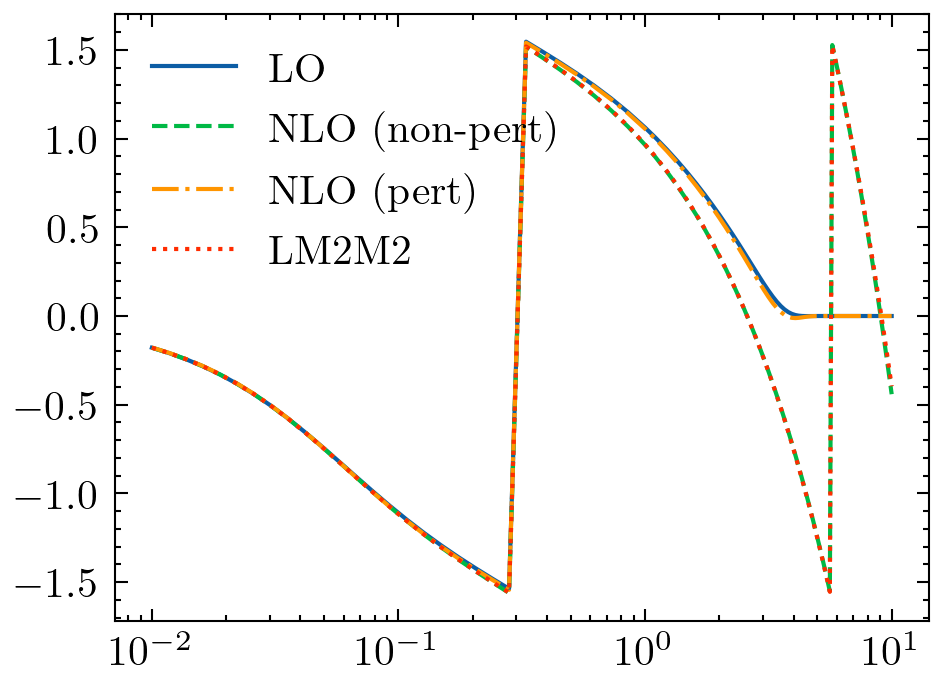

In [22]:
fig, ax = plt.subplots(dpi=300)
fig.patch.set_facecolor('white')

ax.plot(he4.BETA6*lo[:, 0], lo[:, 1], '-', label='LO')
ax.plot(he4.BETA6*nlo_np[:, 0], nlo_np[:, -1], '--', label='NLO (non-pert)')
ax.plot(he4.BETA6*nlo_p[:, 0], nlo_p[:, -1], '-.', label='NLO (pert)')
ax.plot(he4.BETA6*lm2m2[:, 0], lm2m2[:, 1], ':', label='LM2M2')

ax.legend()
ax.set_xscale('log');

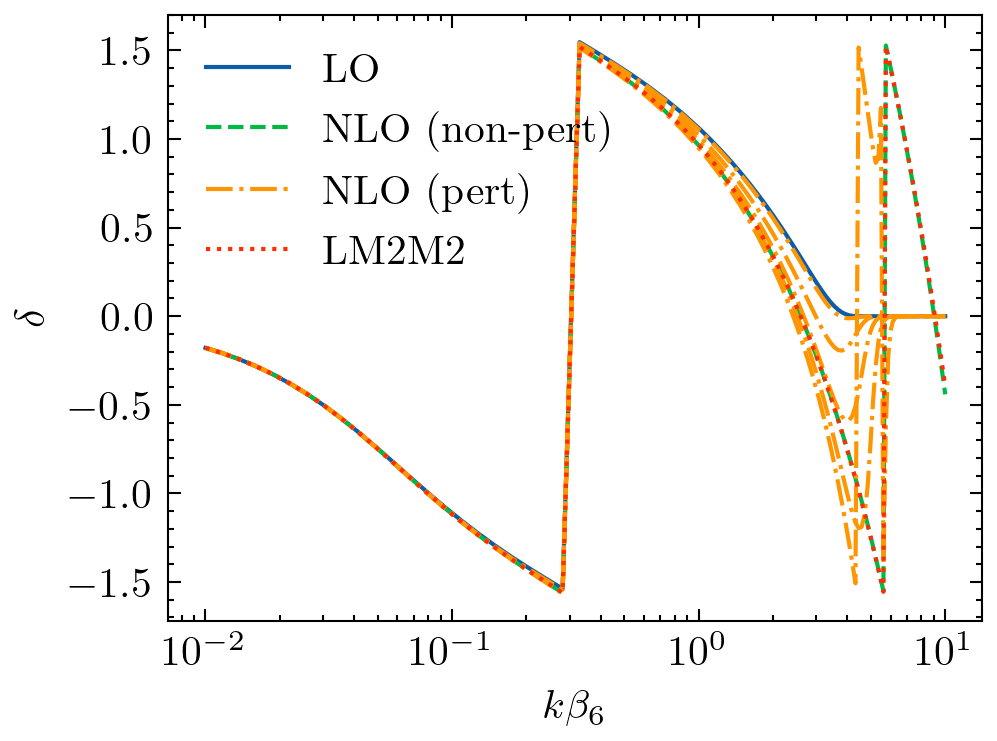

In [23]:
fig, ax = plt.subplots(dpi=300)
fig.patch.set_facecolor('white')

ax.plot(he4.BETA6*lo[:, 0], lo[:, 1], '-', label='LO', color='C0')
ax.plot(he4.BETA6*nlo_np[:, 0], nlo_np[:, -1], '--', label='NLO (non-pert)', color='C1')

first = True
for i in range(-1, -6, -1):
    ax.plot(he4.BETA6*nlo_p[:, 0], nlo_p[:, i], '-.', label='NLO (pert)' if first else '', color='C2')
    first = False
    
ax.plot(he4.BETA6*lm2m2[:, 0], lm2m2[:, 1], ':', label='LM2M2', color='C3')

ax.legend()
ax.set_xlabel(r'$k\beta_6$')
ax.set_ylabel(r'$\delta$')
ax.set_xscale('log');

In [24]:
rg_flow_nlo_p = np.loadtxt('datfiles/rg_flows/nonlocal_nlo_p.txt')
Rs_nlo_p = rg_flow_nlo_p[:, 0]

In [25]:
Rs_nlo_p.shape, nlo_p.shape

((38,), (100, 39))

1.0000000000000002


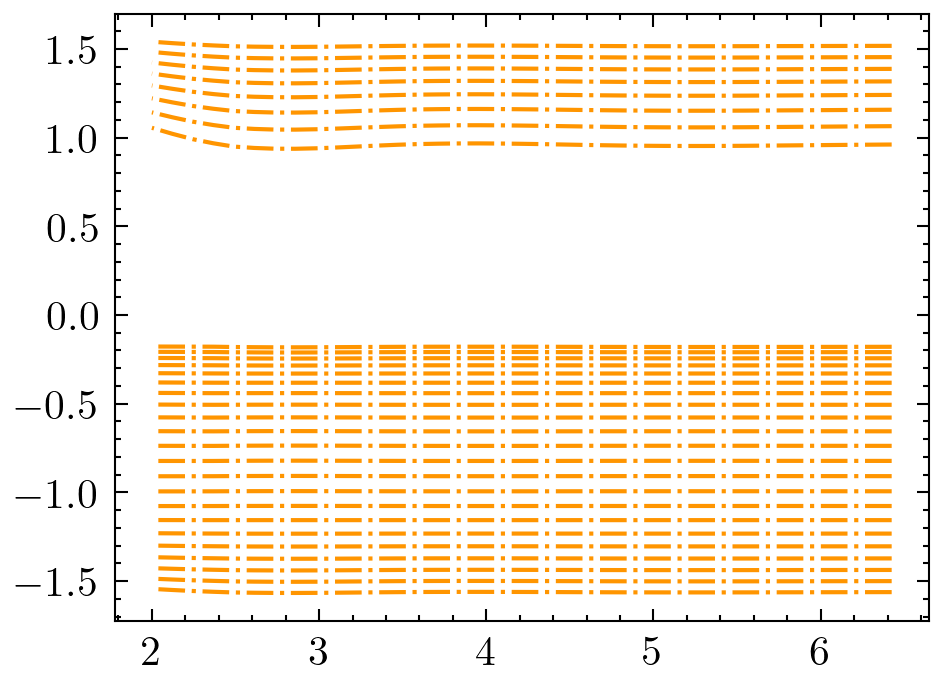

In [26]:
index = 30
print(nlo_p[index-1, 0]*he4.BETA6)

fig, ax = plt.subplots(dpi=300)
fig.patch.set_facecolor('white')

ax.plot(he4.BETA6 / Rs_nlo_p, nlo_p[:index, 1:].T, '-.', label='NLO (pert)' if first else '', color='C2');

# ax.set_xscale('log');

In [27]:
Delta = 3*np.pi

def make_continuous(ps, index=-1):
    deltas = ps[:, index]
    deltas_copy = []
    shift = 0
    for i in range(deltas.size - 1):
        deltas_copy.append(deltas[i] + shift)
        if np.abs(deltas[i] - deltas[i+1]) > 1:
            shift -= np.pi
    deltas_copy.append(deltas[-1] + shift)
    return np.array(deltas_copy) + Delta


def make_lo_continuous(ps):
    deltas = ps[:, 1]
    deltas_copy = []
    shift = 0
    for i in range(deltas.size - 1):
        deltas_copy.append(deltas[i] + shift)
        if deltas[i] < deltas[i+1] and ps[i, 0] < 0.5:
            shift -= np.pi
    deltas_copy.append(deltas[-1] + shift)
    return np.array(deltas_copy) + np.pi + Delta

In [28]:
lm2m2_cont = make_continuous(lm2m2)
lo_cont = make_continuous(lo)
nlo_p_cont = make_continuous(nlo_p, index=1)
nlo_np_cont = make_continuous(nlo_np)

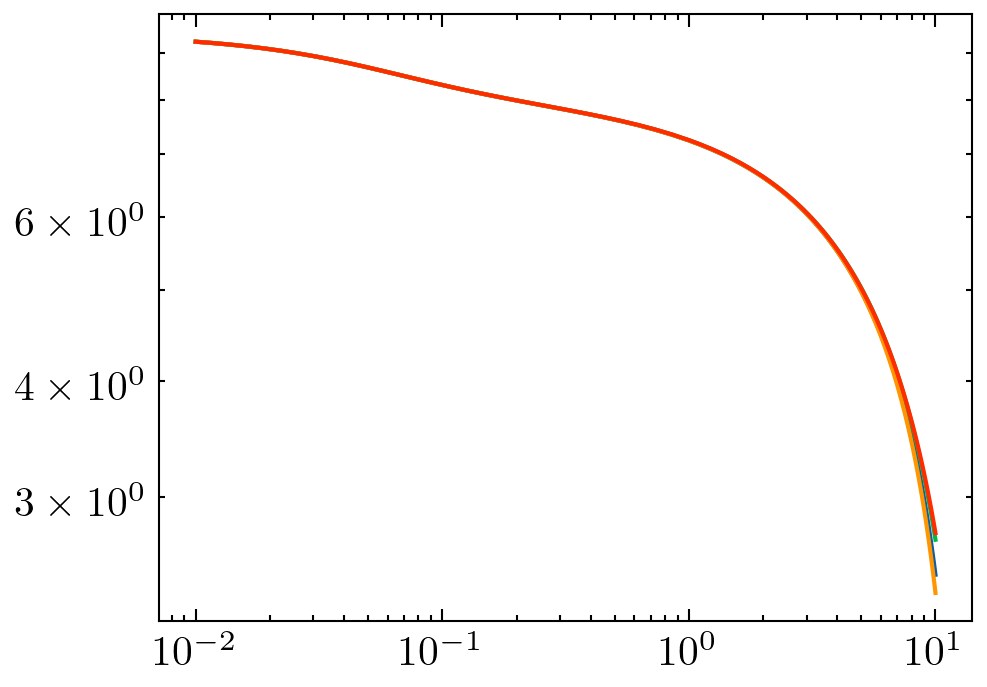

In [29]:
x = lm2m2[:, 0]

fig, ax = plt.subplots(dpi=300)
fig.patch.set_facecolor('white')

ax.plot(he4.BETA6*x, lo_cont)
ax.plot(he4.BETA6*x, nlo_np_cont)
ax.plot(he4.BETA6*x, nlo_p_cont)
ax.plot(he4.BETA6*x, lm2m2_cont)
plt.xscale('log');
plt.yscale('log');

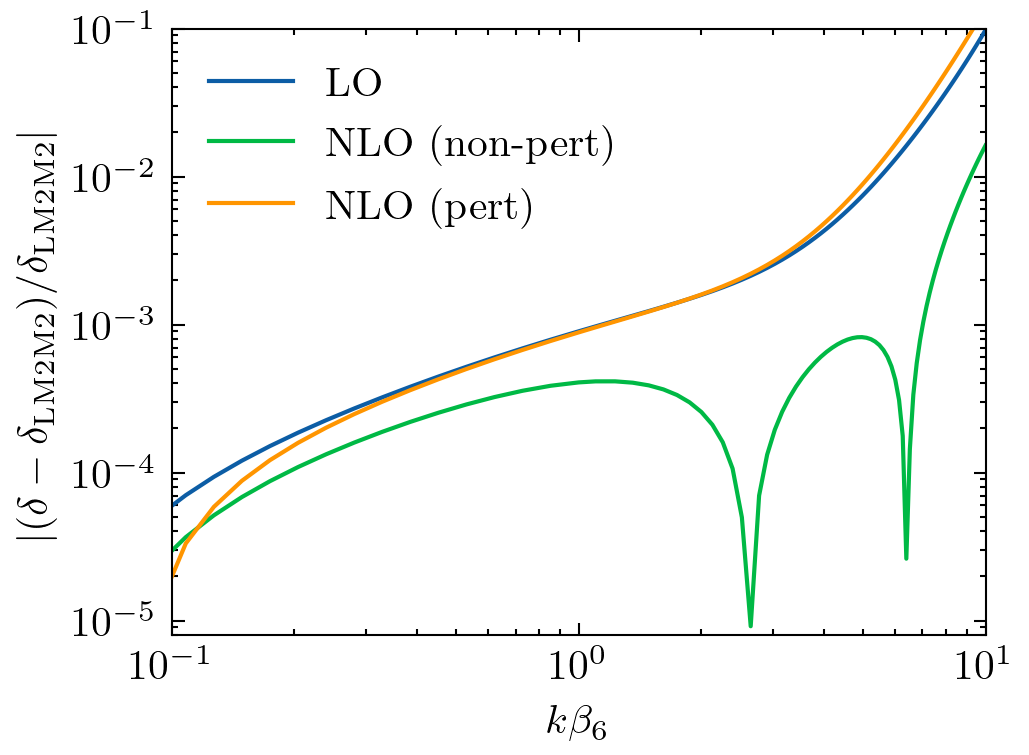

In [33]:
fig, ax = plt.subplots(dpi=300)
fig.patch.set_facecolor('white')

x = lm2m2[:, 0]

ax.plot(he4.BETA6*x, np.abs((lo_cont - lm2m2_cont) / lm2m2_cont), label='LO')
ax.plot(he4.BETA6*x, np.abs((nlo_np_cont - lm2m2_cont) / lm2m2_cont), label='NLO (non-pert)')
ax.plot(he4.BETA6*x, np.abs((nlo_p_cont - lm2m2_cont) / lm2m2_cont), label='NLO (pert)')
# plt.plot(he4.BETA6*x, nlo_p_cont)
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.set_xlim([0.1, 10])
ax.set_ylim([8e-6, 1e-1])

ax.set_xlabel(r'$k\beta_6$')
ax.set_ylabel(r'$|(\delta - \delta_{\rm LM2M2})/\delta_{\rm LM2M2}|$');

plt.savefig('figures/lepage.pdf')

In [24]:
ere0 = -1/he4.A0
ere1 = -1/he4.A0 + he4.R0/2*x**2

K_ere0 = x / ere0
K_ere1 = x / ere1

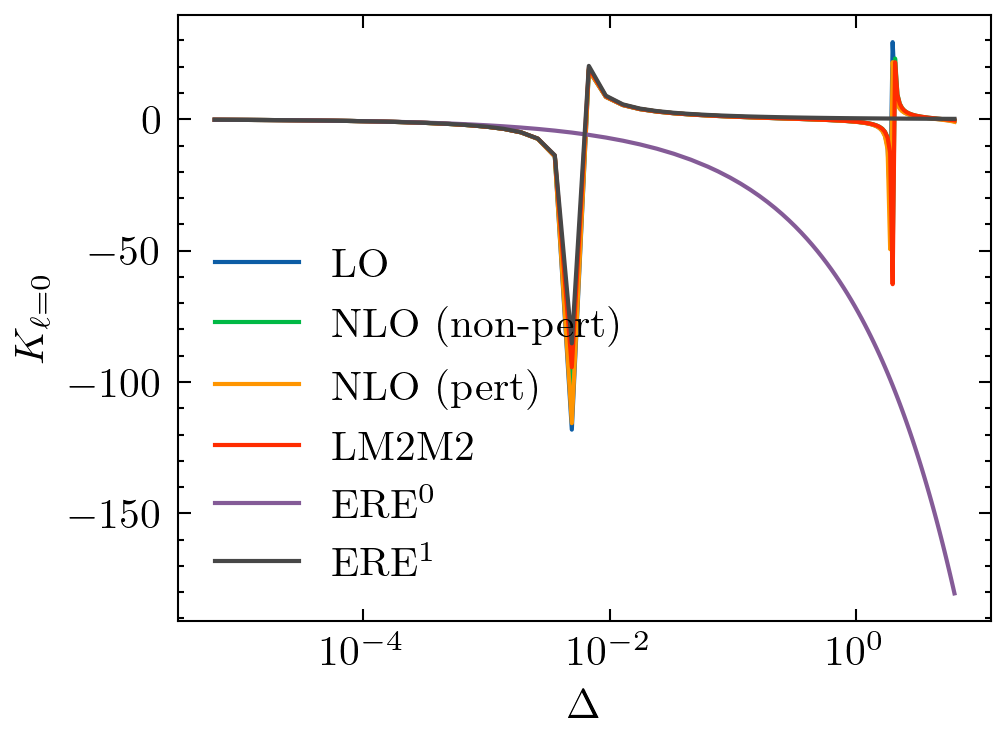

In [27]:
fig, ax = plt.subplots(dpi=300)
fig.patch.set_facecolor('white')

ax.plot((he4.BETA6*x/4)**2, np.tan(lo_cont), label='LO')
ax.plot((he4.BETA6*x/4)**2, np.tan(nlo_np_cont), label='NLO (non-pert)')
ax.plot((he4.BETA6*x/4)**2, np.tan(nlo_p_cont), label='NLO (pert)')
ax.plot((he4.BETA6*x/4)**2, np.tan(lm2m2_cont), label='LM2M2')
ax.plot((he4.BETA6*x/4)**2, K_ere0, label='ERE${}^0$')
ax.plot((he4.BETA6*x/4)**2, K_ere1, label='ERE${}^1$')

# plt.plot(he4.BETA6*x, nlo_p_cont)
ax.set_xscale('log')
# ax.set_yscale('log')
ax.legend()

ax.set_xlabel(r'$\Delta$')
ax.set_ylabel(r'$K_{\ell=0}$');

In [11]:
f_lm2m2 = interp1d(lm2m2[:, 0], lm2m2_cont, kind='cubic')
f_lo = interp1d(nlo_p[:, 0], lo_cont, kind='cubic')
f_nlo_np = interp1d(nlo_p[:, 0], nlo_np_cont, kind='cubic')
f_nlo_p = interp1d(nlo_p[:, 0], nlo_p_cont, kind='cubic')

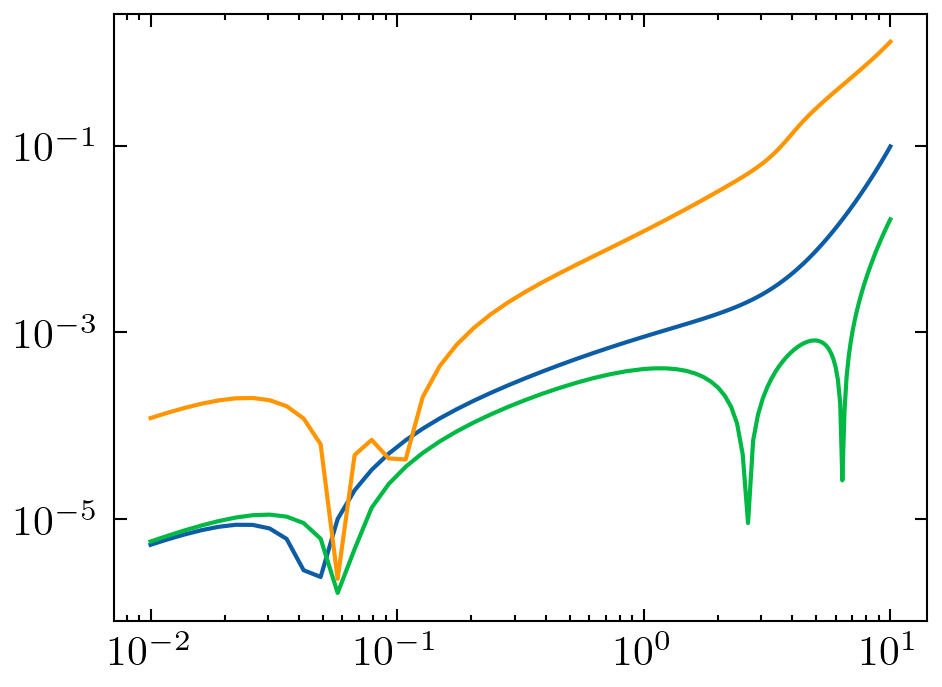

In [12]:
fig, ax = plt.subplots(dpi=300)
fig.patch.set_facecolor('white')

ax.plot(he4.BETA6*x, np.abs((f_lo(x) - f_lm2m2(x)) / f_lm2m2(x)))
ax.plot(he4.BETA6*x, np.abs((f_nlo_np(x) - f_lm2m2(x)) / f_lm2m2(x)))
ax.plot(he4.BETA6*x, np.abs((f_nlo_p(x) - f_lm2m2(x)) / f_lm2m2(x)))

ax.set_xscale('log');
ax.set_yscale('log')